# **1. Import Library**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


from skopt import BayesSearchCV
from skopt.space import Real, Integer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, mutual_info_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pathlib import Path
project_root = Path.cwd()
pd.options.display.float_format = '{:20.2f}'.format
project_root

PosixPath('/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_for_beginners')

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [4]:
data_path = project_root / "data" / "online_retail_customer_clusters.csv"
data_path

PosixPath('/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_for_beginners/data/online_retail_customer_clusters.csv')

In [5]:
df = pd.read_csv(data_path)

In [6]:
df.head()

,Customer ID,Recency,Frequency,Monetary,Interpurchase_Time,Clusters,Day_Type,Month_Period
0,12346.00,325.00,12.00,522.62,36.36,3,Weekday,End
1,12347.00,1.00,8.00,4821.69,57.43,3,Weekday,End
2,12348.00,74.00,5.00,1793.95,90.50,3,Weekday,End
3,12349.00,18.00,4.00,3612.54,190.00,3,Weekday,End
4,12352.00,35.00,10.00,1879.04,39.56,2,Weekday,Middle


In [7]:
df_all = df.drop(columns=['Customer ID'])
df_few = df.drop(columns=['Customer ID', 'Month_Period'])

In [8]:
df_few.columns = df_few.columns.str.lower()
df_all.columns = df_all.columns.str.lower()

In [9]:
df_all

,recency,frequency,monetary,interpurchase_time,clusters,day_type,month_period
0,325.00,12.00,522.62,36.36,3,Weekday,End
1,1.00,8.00,4821.69,57.43,3,Weekday,End
2,74.00,5.00,1793.95,90.50,3,Weekday,End
3,18.00,4.00,3612.54,190.00,3,Weekday,End
4,35.00,10.00,1879.04,39.56,2,Weekday,Middle
...,...,...,...,...,...,...,...
4250,180.00,2.00,197.14,397.00,2,Weekday,Middle
4251,7.00,2.00,178.05,118.00,1,Weekday,Beginning
4252,3.00,22.00,2663.90,31.14,3,Weekday,End
4253,476.00,2.00,1231.38,247.00,2,Weekday,Middle


In [10]:
df_all.columns

Index(['recency', 'frequency', 'monetary', 'interpurchase_time', 'clusters',
       'day_type', 'month_period'],
      dtype='object')

In [11]:
df_few.columns

Index(['recency', 'frequency', 'monetary', 'interpurchase_time', 'clusters',
       'day_type'],
      dtype='object')

In [12]:
numerical_cols = ['recency', 'frequency', 'monetary', 'interpurchase_time']
categorical_cols = ['month_period','day_type']

**Key Takepoint(s)**:
- Sepertinya yang dijelaskan pada key takepoint terakhir di notebook [clustering]([Clustering]_Submission_Akhir_BMLP_Andakara_Athaya_Sidiq_(Updated).ipynb), bahwa fitur kategorikal yang ada mendominasi hasil clustering yang didapatkan. Pada persiapan klasifikasi ini, saya memilih kolom clusters sebagai kolom target dan mempersiapkan dua jenis dataframe, yakni yang termasuk kolom kategorikal dan tanpa kolom kategorikal untuk membandingkan kedua kondisi.

# **3. Data Splitting**

In [13]:
df_all_full_train, df_all_test = train_test_split(df_all, test_size=0.2, random_state=1)
df_all_train, df_all_val = train_test_split(df_all_full_train, test_size=0.25, random_state=1)
df_few_full_train, df_few_test = train_test_split(df_few, test_size=0.2, random_state=1)
df_few_train, df_few_val = train_test_split(df_few_full_train, test_size=0.25, random_state=1)

In [14]:
len(df_all_train), len(df_all_val), len(df_all_test)

(2553, 851, 851)

In [15]:
len(df_few_train), len(df_few_val), len(df_few_test)

(2553, 851, 851)

In [16]:
df_all_train = df_all_train.reset_index(drop=True)
df_all_val = df_all_val.reset_index(drop=True)
df_all_test = df_all_test.reset_index(drop=True)
df_all_full_train = df_all_full_train.reset_index(drop=True)

In [17]:
df_few_train = df_few_train.reset_index(drop=True)
df_few_val = df_few_val.reset_index(drop=True)
df_few_test = df_few_test.reset_index(drop=True)
df_few_full_train = df_few_full_train.reset_index(drop=True)

In [18]:
y_all_train = df_all_train.clusters.values
y_all_val = df_all_val.clusters.values 
y_all_test = df_all_test.clusters.values

del df_all_train['clusters']
del df_all_val['clusters']
del df_all_test['clusters']

In [19]:
y_few_train = df_few_train.clusters.values
y_few_val = df_few_val.clusters.values 
y_few_test = df_few_test.clusters.values

del df_few_train['clusters']
del df_few_val['clusters']
del df_few_test['clusters']

**Key Takepoint(s)**:
- Pembagian dataset dilakukan menggunakan pendekatan [holdout validation](https://medium.com/data-science/when-training-a-model-you-will-need-training-validation-and-holdout-datasets-7566b2eaad80) dengan membagi data test menjadi dua yang terdiri dari data validasi untuk pelatihan dan data test untuk evaluasi akhir performa model. Hal ini dilakukan untuk menghindari overfitting dan  memastikan model dapat menggeneralisasi dengan baik untuk data baru. 

# (Additional) Simple EDA

In [20]:
df_all_full_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3404 entries, 0 to 3403
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   recency             3404 non-null   float64
 1   frequency           3404 non-null   float64
 2   monetary            3404 non-null   float64
 3   interpurchase_time  3404 non-null   float64
 4   clusters            3404 non-null   int64  
 5   day_type            3404 non-null   object 
 6   month_period        3404 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 186.3+ KB


In [21]:
df_all_full_train.clusters.value_counts()

clusters
1    1100
3     983
2     963
0     358
Name: count, dtype: int64

In [22]:
df_all_full_train[numerical_cols].corrwith(df_all_full_train.clusters).abs()

recency                              0.02
frequency                            0.01
monetary                             0.02
interpurchase_time                   0.03
dtype: float64

In [23]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_all.clusters)

In [24]:
mi = df_all[categorical_cols].apply(mutual_info_churn_score)
mi

month_period                   0.98
day_type                       0.33
dtype: float64

**Key Takepoint(s)**:
- Terlihat bahwa setiap kolom numerikal memiliki korelasi yang sangat kecil dengan kolom target, sedangkan kolom month_period memiliki korelasi yang hampir sempurna dengan kolom target. Hal ini berarti kolom numerik akan menjadi prediktor yang lemah, sedangkan month_period dapat diartikan sebagai dasar utama dalam membuat cluster sebelumnya.

# (Additional) Preprocessing

In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [26]:
preprocessor_df_all = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

In [27]:
preprocessor_df_few = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
    ])

In [28]:
X_all_train = preprocessor_df_all.fit_transform(df_all_train)
X_all_val = preprocessor_df_all.transform(df_all_val)
X_all_test = preprocessor_df_all.transform(df_all_test)

X_all_train = X_all_train.toarray() if hasattr(X_all_train, "toarray") else X_all_train
X_all_val = X_all_val.toarray() if hasattr(X_all_val, "toarray") else X_all_val
X_all_test = X_all_test.toarray() if hasattr(X_all_test, "toarray") else X_all_test

print(f"X_train shape: {X_all_train.shape}")
print(f"X_val shape: {X_all_val.shape}")
print(f"X_test shape: {X_all_test.shape}")


X_train shape: (2553, 7)
X_val shape: (851, 7)
X_test shape: (851, 7)


In [29]:
X_few_train = preprocessor_df_few.fit_transform(df_few_train)
X_few_val = preprocessor_df_few.transform(df_few_val)
X_few_test = preprocessor_df_few.transform(df_few_test)

X_few_train = X_few_train.toarray() if hasattr(X_few_train, "toarray") else X_few_train
X_few_val = X_few_val.toarray() if hasattr(X_few_val, "toarray") else X_few_val
X_few_test = X_few_test.toarray() if hasattr(X_few_test, "toarray") else X_few_test

print(f"X_train shape: {X_few_train.shape}")
print(f"X_val shape: {X_few_val.shape}")
print(f"X_test shape: {X_few_test.shape}")

X_train shape: (2553, 4)
X_val shape: (851, 4)
X_test shape: (851, 4)


**Key Takepoint(s)**:
- Scaling dilakukan karena pada pelatihan model nanti, salah satunya saya akan menggunakan model logistic regression yang mungkin sensitif dengan skala data.

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

In [30]:
models_all = {}

# Logistic Regression
models_all['Logistic Regression'] = LogisticRegression(max_iter=1000, random_state=42)
models_all['Logistic Regression'].fit(X_all_train, y_all_train)
y_pred_lr = models_all['Logistic Regression'].predict(X_all_val)
lr_accuracy = accuracy_score(y_all_val, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Random Forest
models_all['Random Forest'] = RandomForestClassifier(random_state=42)
models_all['Random Forest'].fit(X_all_train, y_all_train)
y_pred_rf = models_all['Random Forest'].predict(X_all_val)
rf_accuracy = accuracy_score(y_all_val, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# XGBoost 
models_all['XGBoost'] = xgb.XGBClassifier(
    objective='multi:softmax',  
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)
models_all['XGBoost'].fit(X_all_train, y_all_train)
y_pred_xgb = models_all['XGBoost'].predict(X_all_val)
xgb_accuracy = accuracy_score(y_all_val, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

Logistic Regression Accuracy: 1.0000


Random Forest Accuracy: 1.0000
XGBoost Accuracy: 1.0000


In [31]:
models_few = {}

# Logistic Regression
models_few['Logistic Regression'] = LogisticRegression(max_iter=1000, random_state=42)
models_few['Logistic Regression'].fit(X_few_train, y_few_train)
y_pred_lr = models_few['Logistic Regression'].predict(X_few_val)
lr_accuracy = accuracy_score(y_few_val, y_pred_lr)
print(f"Akurasi Logistic Regression: {lr_accuracy:.4f}")

# Random Forest
models_few['Random Forest'] = RandomForestClassifier(random_state=42)
models_few['Random Forest'].fit(X_few_train, y_few_train)
y_pred_rf = models_few['Random Forest'].predict(X_few_val)
rf_accuracy = accuracy_score(y_few_val, y_pred_rf)
print(f"Akurasi Random Forest: {rf_accuracy:.4f}")

# XGBoost 
models_few['XGBoost'] = xgb.XGBClassifier(
    objective='multi:softmax',  
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)
models_few['XGBoost'].fit(X_few_train, y_few_train)
y_pred_xgb = models_few['XGBoost'].predict(X_few_val)
xgb_accuracy = accuracy_score(y_few_val, y_pred_xgb)
print(f"Akurasi XGBoost: {xgb_accuracy:.4f}")

Akurasi Logistic Regression: 0.3220
Akurasi Random Forest: 0.3478
Akurasi XGBoost: 0.3807


**Key Takepoint(s)**:
- Pada tahap ini dilatih inisialisasi ketiga model yang dipilih, yakni Logistic Regression, Random Forest, dan XGBoost.
- Semua model mencapai akurasi sempurna pada dataset lengkap, namun XGBoost menunjukkan performa terbaik pada dataset terbatas (yang hanya mengandung fitur numerikal). Membuktikan bahwa fitur numerikal adalah prediktor lemah, sedangkan fitur kategorikal adalah prediktor sempurna.
- **Logistic Regression**: 
  - Diimplementasikan dengan parameter max_iter=1000 dan random_state=42
- **Random Forest Classifier**:
  - Diimplementasikan dengan parameter default, hanya mengatur random_state=42
- **XGBoost Classifier**:
  - Dikonfigurasi dengan objective='multi:softmax', n_estimators=100, learning_rate=0.1, max_depth=6
  - Konfigurasi ini dilakukan berdasarkan kira-kira dan domain knowledge
- Konfigurasi dari model ini hanya secara awal saja, model terbaik perlu dilakukan konfigurasi dari hasil tuning.

## **b. Evaluasi Model Klasifikasi**

Best model: Logistic Regression

Classificationx Report Pada Data Lengkap:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00       274
           2       1.00      1.00      1.00       245
           3       1.00      1.00      1.00       248

    accuracy                           1.00       851
   macro avg       1.00      1.00      1.00       851
weighted avg       1.00      1.00      1.00       851



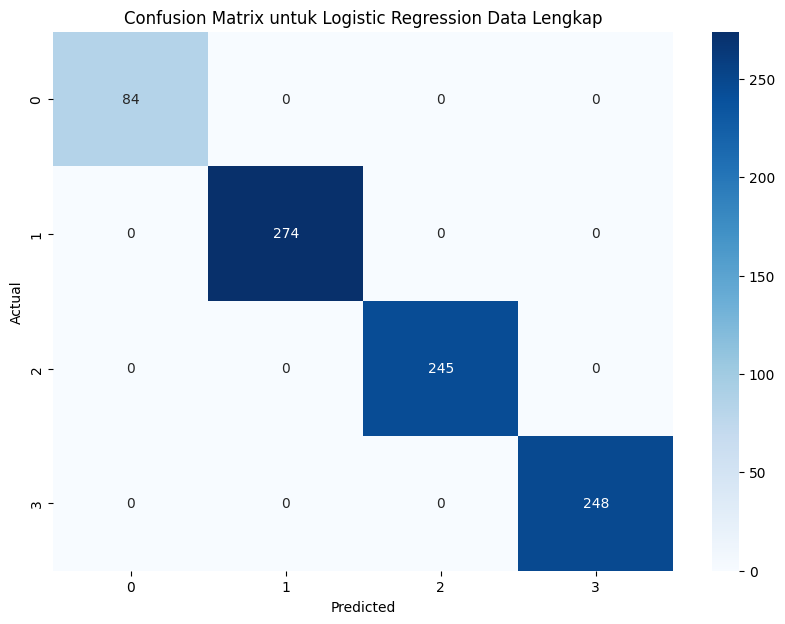

In [32]:
best_model_name = max(models_all, key=lambda model: accuracy_score(y_all_val, models_all[model].predict(X_all_val)))
best_model = models_all[best_model_name]
print(f"Best model: {best_model_name}")

y_pred = best_model.predict(X_all_val)
print("\nClassificationx Report Pada Data Lengkap:")
print(classification_report(y_all_val, y_pred))

cm = confusion_matrix(y_all_val, y_pred)
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix untuk {best_model_name} Data Lengkap')
plt.show()

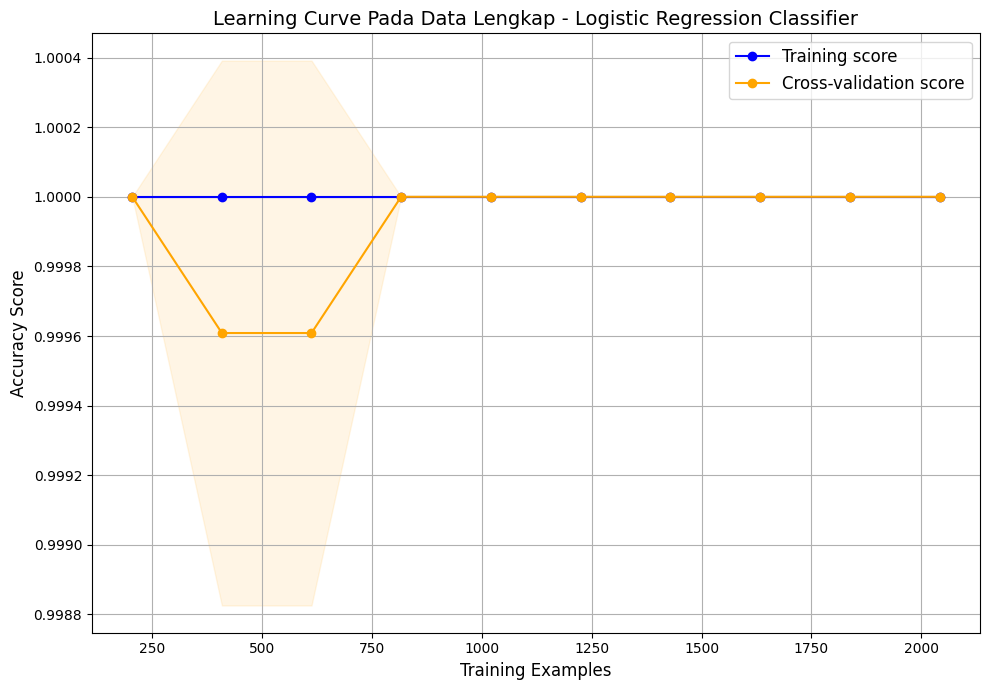

In [33]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,  
    X=X_all_train,
    y=y_all_train,
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5,  
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.grid()
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-validation score')
plt.title(f'Learning Curve Pada Data Lengkap - {best_model_name} Classifier', fontsize=14)
plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

Best model: XGBoost

Classificationx Report pada Data Terbatas:
              precision    recall  f1-score   support

           0       0.15      0.04      0.06        84
           1       0.40      0.45      0.42       274
           2       0.38      0.37      0.38       245
           3       0.37      0.43      0.40       248

    accuracy                           0.38       851
   macro avg       0.33      0.32      0.31       851
weighted avg       0.36      0.38      0.37       851



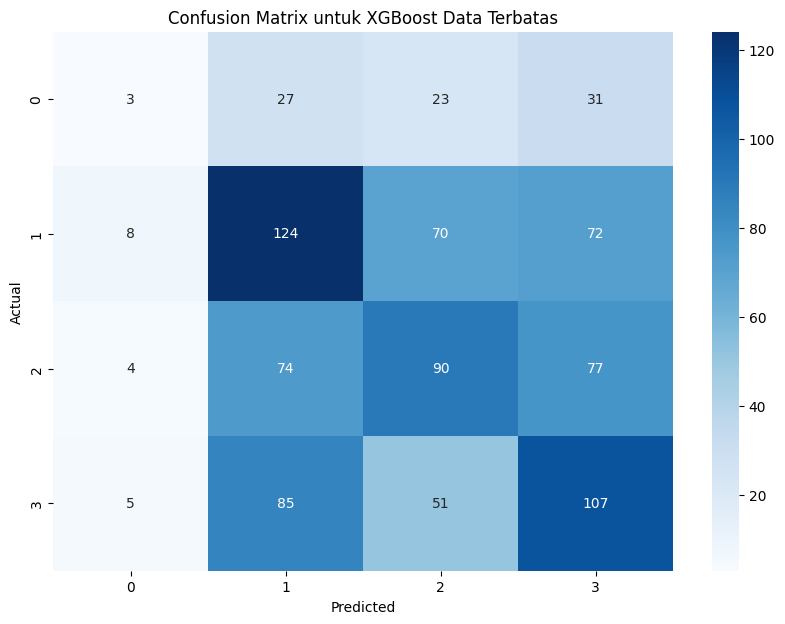

In [34]:
best_model_name = max(models_few, key=lambda model: accuracy_score(y_few_val, models_few[model].predict(X_few_val)))
best_model = models_few[best_model_name]
print(f"Best model: {best_model_name}")

y_few_pred = best_model.predict(X_few_val)
print("\nClassificationx Report pada Data Terbatas:")
print(classification_report(y_few_val, y_few_pred))

cm = confusion_matrix(y_few_val, y_few_pred)
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix untuk {best_model_name} Data Terbatas')
plt.show()

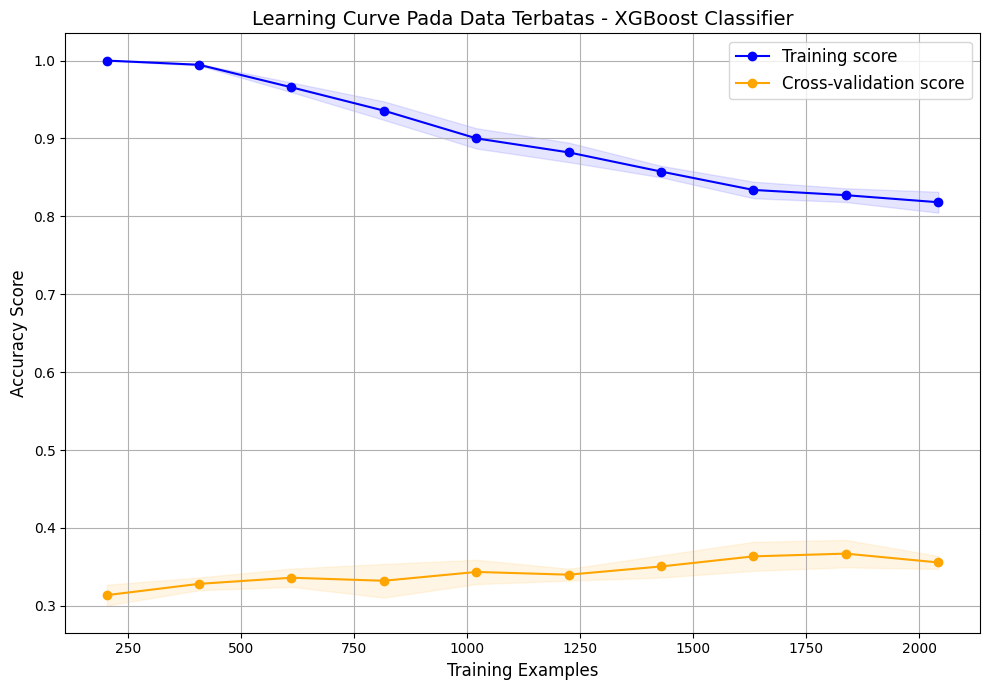

In [35]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,  
    X=X_few_train,
    y=y_few_train,
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5,  
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.grid()
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-validation score')
plt.title(f'Learning Curve Pada Data Terbatas - {best_model_name} Classifier', fontsize=14)
plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

**Key Takepoint(s)**:
- **Performa Dataset Lengkap**:
    - **Model terbaik**: Semua Model
    - **Akurasi keseluruhan**: 100% (klasifikasi sempurna)
    - **Metrik per kelas**: Semua kelas menunjukkan presisi, recall, dan F1-score sempurna (1.00)
    - **Konsistensi**: Performa sempurna di semua metrik evaluasi
    - **Kompleksitas model**: Bahkan model sederhana seperti Regresi Logistik mencapai hasil sempurna

- **Performa Dataset Terbatas** (tanpa month_period dan day_type):
    - **Model terbaik**: XGBoost (diperlukan algoritma yang lebih kompleks)
    - **Akurasi keseluruhan**: Hanya 38% (penurunan drastis)
    - **Kelas 0**: Performa sangat buruk (precision 0.15, recall 0.04)
    - **Kelas 1-3**: Klasifikasi lemah dengan metrics berkisar antara 0.37-0.45
    - **Paling menantang**: Kelas 0 dengan recall terendah (0.04)
    - **Ketidakseimbangan**: Perbedaan mencolok antara rata-rata makro (0.33) dan rata-rata berbobot (0.36-0.38)

- **Performa Setelah Tuning**:
    - **Akurasi**: Meningkat menjadi 42.66% (+5%)
    - **Kelas 0**: Gagal total dengan precision dan recall 0.00
    - **Kelas 1**: Menunjukkan peningkatan signifikan (recall 0.61)
    - **Kelas 2**: Memiliki precision tertinggi (0.50) tapi recall rendah (0.31)

- Model terbaik untuk kondisi data terbatas adalah XGBoost, sedangkan untuk data lengkap semua model konsisten memiliki performa yang sempurna.
- Logistic Regression dipilih untuk merepresentasikan model dengan data lengkap karena kesederhanaan.
- Pemilihan XGBoost sebagai model terbaik untuk data terbatas menunjukkan diperlukan hubungan yang lebih kompleks.
- Penurunan performa yang drastis (100% menjadi 38-43%) mengkonfirmasi fitur kategorikal adalah penentu utama dalam pengelompokan.
- Perubahan drastis pada Kelas 0 dari yang sebelumnya mudah diidentifikasi menjadi yang paling sulit menunjukkan ketergantungan pada fitur kategorikal.
- Terlihat pada learning curve dari model dengan data lengkap yang tidak memiliki gap dan hampir langsung mendapatkan akurasi sempurna, sedangkan pada model dengan data terbatas terlihat terjadinya fenomena underfitting.

## **c. Tuning Model Klasifikasi (Optional)**

In [36]:
search_spaces = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'min_child_weight': Integer(1, 10),
    'max_depth': Integer(3, 10),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(1e-9, 1.0, prior='log-uniform'),
    'n_estimators': Integer(50, 300)
}

bayes_search = BayesSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softmax', 
        random_state=42
    ),
    search_spaces=search_spaces,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='roc_auc_ovr', 
    random_state=42
)

bayes_search.fit(X_few_train, y_few_train)

print(f"Parameter terbaik yang ditemukan: {bayes_search.best_params_}")
print(f"Cross-validation score terbaik: {bayes_search.best_score_:.4f}")

best_xgb = bayes_search.best_estimator_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

In [37]:
y_proba_xgb = best_xgb.predict_proba(X_few_val)

y_pred_xgb = best_xgb.predict(X_few_val)
xgb_accuracy = accuracy_score(y_few_val, y_pred_xgb)
print(f"Akurasi XGBoost: {xgb_accuracy:.4f}")

auc_score = roc_auc_score(y_few_val, y_proba_xgb, multi_class='ovr')
print(f" AUC-ROC XGBoost: {auc_score:.4f}")

ap_scores = []
for i in range(y_proba_xgb.shape[1]):
    y_true_binary = (y_few_val == i).astype(int)
    ap_scores.append(average_precision_score(y_true_binary, y_proba_xgb[:, i]))
ap_score = np.mean(ap_scores)
print(f" Average Precision XGBoost: {ap_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_few_val, y_pred_xgb))

Akurasi XGBoost: 0.4266
 AUC-ROC XGBoost: 0.6342
 Average Precision XGBoost: 0.3686

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        84
           1       0.41      0.61      0.49       274
           2       0.50      0.31      0.38       245
           3       0.42      0.48      0.45       248

    accuracy                           0.43       851
   macro avg       0.33      0.35      0.33       851
weighted avg       0.40      0.43      0.40       851



/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_for_beginners/.dicoding-lmlfb-venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_for_beginners/.dicoding-lmlfb-venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_for_beginners/.dicoding-lmlfb-venv/lib/python3.12/site-packages/sk

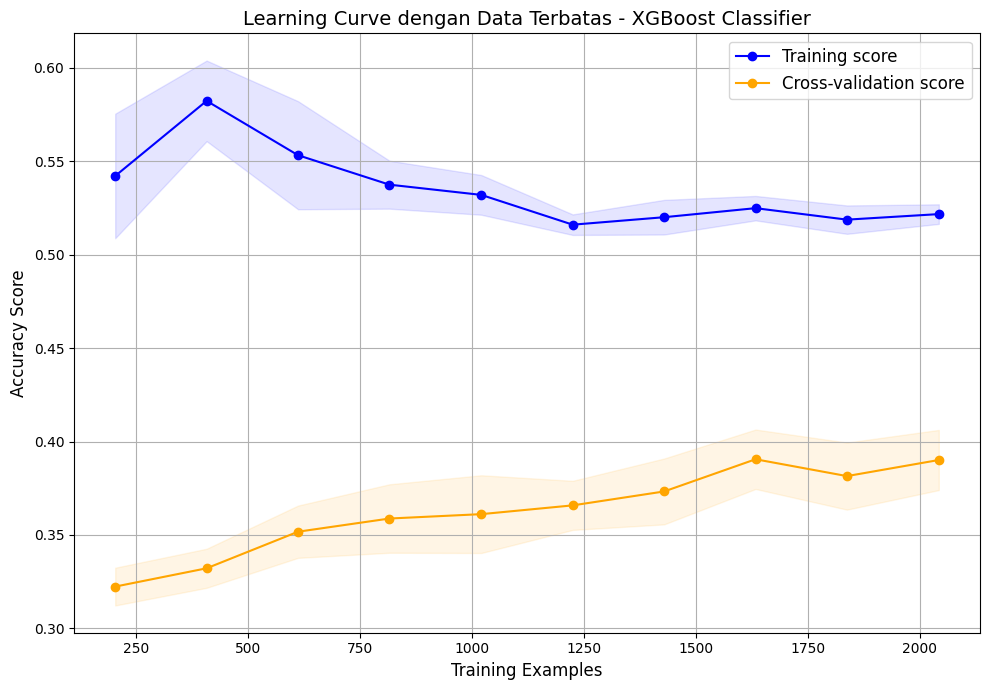

In [38]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_xgb,
    X=X_few_train,
    y=y_few_train,
    train_sizes=np.linspace(0.1, 1.0, 10),  
    cv=5,  
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.grid()
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-validation score')
plt.title('Learning Curve dengan Data Terbatas - XGBoost Classifier', fontsize=14)
plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

**Key Takepoint(s)**:
- Tuning hyperparameter berhasil meningkatkan akurasi keseluruhan sekitar 5% (dari 38% menjadi 42.66%)
- Kelas 0 mengalami penurunan drastis dengan precision dan recall 0.00 (gagal total)
- Kelas 1 mengalami peningkatan terbesar dalam kemampuan deteksi (recall 0.61)
- Kelas 2 memiliki precision tertinggi (0.50) namun masih memiliki recall rendah (0.31)
- Kelas 3 menunjukkan performa paling seimbang antara precision (0.42) dan recall (0.48)
- Terlihat trade-off yang jelas, di mana model lebih baik dalam mendeteksi kelas 1 dan 3, namun kehilangan kemampuan untuk mengidentifikasi kelas 0
- AUC-ROC (0.6342) dan Average Precision (0.3686) menunjukkan performa yang terbatas
- Learning curve mengindikasikan model mulai konvergen tetapi pada akurasi yang jauh dari optimal
- Hasil tuning menunjukkan bahwa bahkan dengan optimasi parameter, model tetap kesulitan mengklasifikasikan tanpa fitur kategorikal

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

In [39]:
y_test_pred = best_xgb.predict(X_few_test)
test_accuracy = accuracy_score(y_few_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_few_test, y_test_pred))

Test Accuracy: 0.3831

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        85
           1       0.38      0.62      0.47       271
           2       0.41      0.25      0.31       251
           3       0.38      0.39      0.39       244

    accuracy                           0.38       851
   macro avg       0.29      0.32      0.29       851
weighted avg       0.35      0.38      0.35       851



In [40]:
y_test_pred = models_all['Logistic Regression'].predict(X_all_test)
test_accuracy = accuracy_score(y_all_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_all_test, y_test_pred))

Test Accuracy: 1.0000

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        85
           1       1.00      1.00      1.00       271
           2       1.00      1.00      1.00       251
           3       1.00      1.00      1.00       244

    accuracy                           1.00       851
   macro avg       1.00      1.00      1.00       851
weighted avg       1.00      1.00      1.00       851



# Analisis Akhir Hasil Klasifikasi

## Perbandingan Hasil Evaluasi

### Kondisi Dataset Lengkap vs Terbatas
1. **Dataset Lengkap**:
   - **Akurasi**: 100% untuk semua model (Logistic Regression, Random Forest, XGBoost) baik pada data validation dan test
   - **Performa per kelas**: Sempurna (precision, recall, F1-score = 1.00)
   - **Learning curve**: Konvergensi cepat, tidak ada gap (tidak ada overfitting)
   - **Model terbaik**: Bahkan model sederhana seperti Logistic Regression mencapai hasil sempurna

2. **Dataset Terbatas** (tanpa month_period & day_type) sebelum tuning:
   - **Akurasi**: Hanya 38% pada data validation dengan model terbaik (XGBoost) 
   - **Kelas 0**: Performa sangat buruk (precision 0.15, recall 0.04)
   - **Kelas 1-3**: Klasifikasi lemah dengan metrics berkisar antara 0.37-0.45
   - **Learning curve**: Gap besar antara training dan validation score

### Hasil Setelah Tuning (Dataset Terbatas)
- **Akurasi**: Meningkat menjadi 42.66% (+5%) pada data validation dan 38% pada data test
- **AUC-ROC**: 0.6342 (menurun dibandingkan versi sebelumnya)
- **Average Precision**: 0.3686
- **Kelas 0**: Gagal total dengan precision dan recall 0.00
- **Kelas 1**: Menunjukkan peningkatan signifikan (recall 0.61)
- **Kelas 2**: Memiliki precision tertinggi (0.50) tapi recall rendah (0.31)
- **Kelas 3**: Performa seimbang (precision 0.42, recall 0.48)

## Identifikasi Kelemahan Model

1. **Ketergantungan pada Fitur Kategorikal**:
   - Perbedaan akurasi yang ekstrem (100% vs 38-43%) menunjukkan clustering asli sangat bergantung pada fitur kategorikal
   - Penghilangan month_period dan day_type menyebabkan model kehilangan kemampuan membedakan kelas
   - Fitur numerik sendiri tidak mampu menangkap pola pengelompokkan dengan baik

2. **Perubahan Drastis pada Kelas 0**:
   - Kelas 0 berubah dari yang paling mudah diidentifikasi (100% akurat) menjadi yang paling sulit (0% akurat) setelah fitur kategorikal dihilangkan
   - Menunjukkan kelas 0 sangat bergantung pada kombinasi fitur kategorikal

3. **Ketidakseimbangan Performa antar Kelas**:
   - Setelah tuning, kelas 1 dan 3 relatif lebih baik daripada kelas 0 dan 2
   - Menandakan fitur numerik masih memiliki daya prediksi terbatas untuk beberapa kelas

4. **Masalah Underfitting**:
   - Learning curve menunjukkan model mulai konvergen namun pada performa yang sub-optimal
   - Gap antara training dan validation score menunjukkan variance relatif tinggi

## Rekomendasi Tindakan Lanjutan
- Meninjau ulang clustering dengan fitur numerikal yang dapat seimbang dengan fitur kategorikal dalam berkontribusi pada hasil clustering.

Secara keseluruhan, hasil menunjukkan bahwa klasifikasi pelanggan sangat bergantung pada fitur kategorikal yang mungkin menangkap pola musiman atau temporal. Tanpa fitur tersebut, fitur numerik sendiri tidak cukup untuk mengidentifikasi pola pengelompokkan pelanggan dengan akurat, meskipun tuning hyperparameter dapat memberikan perbaikan.